# GUV-GrA Size Analysis
### Effect of Gramicidin A concentration on DOPC:DOPG giant unilamellar vesicle size

**System:** DOPC:DOPG (60:40 mol%) + Gramicidin A at 0.01% and 0.02% (w/w)
*(Note: sheet labels in the source file read 60:40 lipid ratio — update this notebook's title/labels if your intended composition was actually 80:20; the numbers themselves are unaffected.)*

**Data:** this public repo ships only a small synthetic **toy dataset** (`data/toy_dataset/toy_guv_sizes.xlsx`) so the notebook runs end-to-end for anyone who clones it. The original measurements (two sheets of GUV diameters, µm, n=120 per condition) are **not included** in this repository — place your own copy at `data/size_distribution_of_guvs.xlsx` (git-ignored) to reproduce the real-data results.

This notebook covers exploratory data analysis and statistical comparison between conditions. It does **not** include image segmentation or shape-deformation analysis, because the workbook contains only extracted diameter values, not the underlying microscopy images. See the README for what raw images would add.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.load_data import load_guv_sizes

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

FIG_DIR = "../figures"

# This public repo ships only the toy dataset (see data/toy_dataset/). Set this to
# False, and place a real workbook at data/size_distribution_of_guvs.xlsx (it's
# git-ignored), to reproduce the real-data results.
USE_TOY_DATA = True

DATA_PATH = "../data/toy_dataset/toy_guv_sizes.xlsx" if USE_TOY_DATA \
    else "../data/size_distribution_of_guvs.xlsx"
print("Using:", DATA_PATH)


Using: ../data/toy_dataset/toy_guv_sizes.xlsx


## 1. Load and tidy the data

> **Toy dataset note:** if `USE_TOY_DATA = True` above, the sheets are randomly
> generated (see `scripts/generate_toy_data.py`) and only exist so this notebook
> runs end-to-end without the real file. Do not report numbers from a toy-data run
> as real results.

In [2]:
xls = pd.ExcelFile(DATA_PATH)
print("Sheets found:", xls.sheet_names)

# Map raw sheet names to clean condition labels. Edit if your sheet names differ.
if USE_TOY_DATA:
    condition_map = {
        xls.sheet_names[0]: "toy GrA 0.01%",
        xls.sheet_names[1]: "toy GrA 0.02%",
    }
else:
    condition_map = {
        xls.sheet_names[0]: "GrA 0.01%",
        xls.sheet_names[1]: "GrA 0.02%",
    }

data = load_guv_sizes(DATA_PATH, condition_map=condition_map)
print(data.groupby("condition").size())
data.head()


Sheets found: ['toy_GrA_0.01pct', 'toy_GrA_0.02pct']
condition
toy GrA 0.01%    20
toy GrA 0.02%    20
dtype: int64


,condition,diameter_um,radius_um,area_um2,volume_um3
0,toy GrA 0.01%,15.89,7.945,198.306832,2100.730370
1,toy GrA 0.01%,10.61,5.305,88.413921,625.381132
2,toy GrA 0.01%,18.16,9.080,259.013005,3135.784108
3,toy GrA 0.01%,19.23,9.615,290.434664,3723.372399
4,toy GrA 0.01%,8.08,4.040,51.275819,276.205743


**Note on derived columns:** `area_um2` and `volume_um3` are *calculated from the diameter
assuming a perfect sphere/circle* — they are not independent measurements. Treat them as
convenience quantities, not as evidence of shape. Real circularity/shape-deformation values
require the source images (see README).

## 2. Descriptive statistics

In [3]:
summary = data.groupby("condition")["diameter_um"].agg(
    n="count", mean="mean", median="median", std="std",
    cv=lambda x: x.std() / x.mean(),
    min="min", max="max",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    skew=lambda x: stats.skew(x),
    kurtosis=lambda x: stats.kurtosis(x),
).round(3)
summary


,n,mean,median,std,cv,min,max,q25,q75,skew,kurtosis
condition,,,,,,,,,,,
toy GrA 0.01%,20,14.806,14.93,3.594,0.243,8.08,20.33,11.225,18.197,-0.208,-1.103
toy GrA 0.02%,20,14.975,12.76,5.793,0.387,9.49,33.19,11.182,17.032,1.666,2.883


In [4]:
summary.to_csv(f"{FIG_DIR}/summary_statistics.csv")
print("Saved summary_statistics.csv")


Saved summary_statistics.csv


## 3. Distribution shape: normal vs. log-normal

In [5]:
for cond, grp in data.groupby("condition"):
    x = grp["diameter_um"]
    sh_stat, sh_p = stats.shapiro(x)
    logx = np.log(x)
    sh_log_stat, sh_log_p = stats.shapiro(logx)
    print(f"{cond}: Shapiro-Wilk on raw diameters   p={sh_p:.4f}")
    print(f"{cond}: Shapiro-Wilk on log(diameters)  p={sh_log_p:.4f}\n")


toy GrA 0.01%: Shapiro-Wilk on raw diameters   p=0.4057
toy GrA 0.01%: Shapiro-Wilk on log(diameters)  p=0.1874

toy GrA 0.02%: Shapiro-Wilk on raw diameters   p=0.0018
toy GrA 0.02%: Shapiro-Wilk on log(diameters)  p=0.1036



GUV sizes from extrusion/electroformation are commonly closer to log-normal than normal.
The Shapiro-Wilk p-values above tell you, for *this* data, which assumption is more
defensible before you pick a parametric test.

## 4. Statistical comparison between conditions

In [6]:
g1, g2 = [grp["diameter_um"].values for _, grp in data.groupby("condition")]
labels = list(data["condition"].unique())

# Non-parametric (robust to non-normal / skewed data, no distribution assumption)
u_stat, u_p = stats.mannwhitneyu(g1, g2, alternative="two-sided")

# Parametric reference (Welch's t-test, does not assume equal variance)
t_stat, t_p = stats.ttest_ind(g1, g2, equal_var=False)

# Effect size: Cohen's d
pooled_std = np.sqrt((g1.std(ddof=1)**2 + g2.std(ddof=1)**2) / 2)
cohens_d = (g1.mean() - g2.mean()) / pooled_std

# Effect size for KS-style comparison of the whole distribution
ks_stat, ks_p = stats.ks_2samp(g1, g2)

print(f"Comparing {labels[0]} vs {labels[1]}  (n1={len(g1)}, n2={len(g2)})")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={u_p:.4g}")
print(f"Welch's t-test: t={t_stat:.3f}, p={t_p:.4g}")
print(f"Cohen's d:      {cohens_d:.3f}")
print(f"KS test (distribution shape): D={ks_stat:.3f}, p={ks_p:.4g}")


Comparing toy GrA 0.01% vs toy GrA 0.02%  (n1=20, n2=20)
Mann-Whitney U: U=218.0, p=0.6359
Welch's t-test: t=-0.111, p=0.9127
Cohen's d:      -0.035
KS test (distribution shape): D=0.250, p=0.5713


**Interpretation guide (fill in once you have run it on your real numbers):**
- Mann-Whitney U tests whether one distribution is stochastically larger than the other —
  the safest default given GUV sizes are usually right-skewed.
- The KS test additionally flags differences in *shape/spread*, not just central tendency —
  relevant here since Gramicidin A is expected to affect membrane packing and could widen
  the size distribution as well as shift its center.
- Cohen's d gives a normal-theory effect size for comparison with literature; report it
  alongside, not instead of, the non-parametric result if the data are non-normal.

## 5. Publication-quality figures

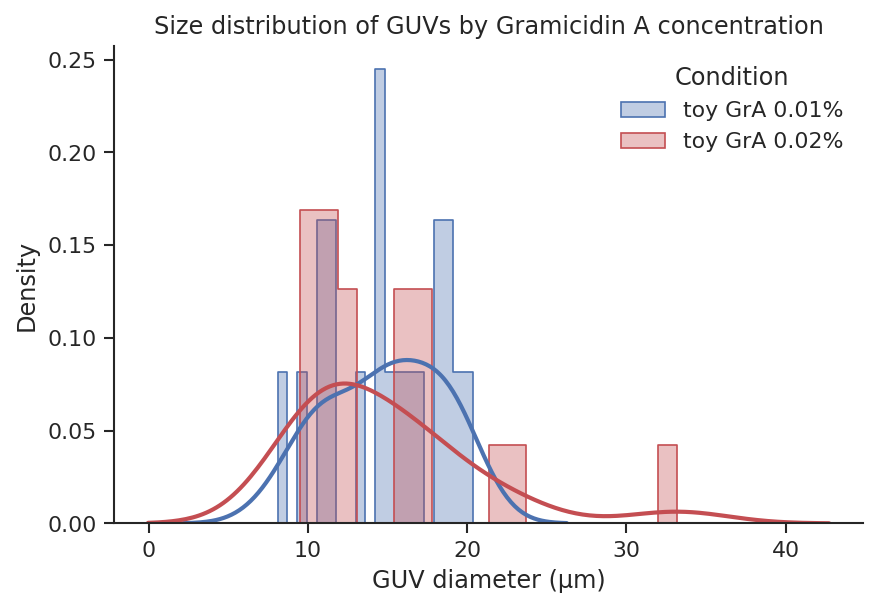

In [7]:
palette = {labels[0]: "#4C72B0", labels[1]: "#C44E52"}

fig, ax = plt.subplots(figsize=(6, 4.2))
for cond, grp in data.groupby("condition"):
    sns.histplot(grp["diameter_um"], bins=20, stat="density", element="step",
                 fill=True, alpha=0.35, color=palette[cond], ax=ax, label=cond)
    sns.kdeplot(grp["diameter_um"], color=palette[cond], ax=ax, lw=2)
ax.set_xlabel("GUV diameter (µm)")
ax.set_ylabel("Density")
ax.set_title("Size distribution of GUVs by Gramicidin A concentration")
ax.legend(title="Condition", frameon=False)
sns.despine()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig1_histogram_kde.png", dpi=300)
fig.savefig(f"{FIG_DIR}/fig1_histogram_kde.svg")
plt.show()


/tmp/ipykernel_487/72762298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="condition", y="diameter_um", palette=palette,


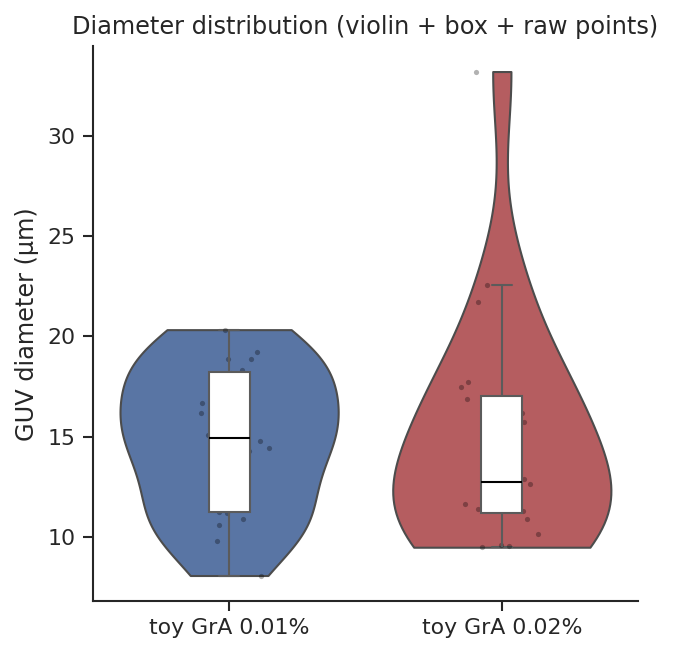

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
sns.violinplot(data=data, x="condition", y="diameter_um", palette=palette,
               inner=None, cut=0, ax=ax)
sns.stripplot(data=data, x="condition", y="diameter_um", color="black",
              alpha=0.3, size=2.5, jitter=0.15, ax=ax)
sns.boxplot(data=data, x="condition", y="diameter_um", width=0.15,
            showcaps=True, boxprops={'facecolor': 'white', 'zorder': 3},
            whiskerprops={'zorder': 3}, medianprops={'color': 'black', 'zorder': 4},
            ax=ax, showfliers=False)
ax.set_xlabel("")
ax.set_ylabel("GUV diameter (µm)")
ax.set_title("Diameter distribution (violin + box + raw points)")
sns.despine()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig2_violin_box.png", dpi=300)
fig.savefig(f"{FIG_DIR}/fig2_violin_box.svg")
plt.show()


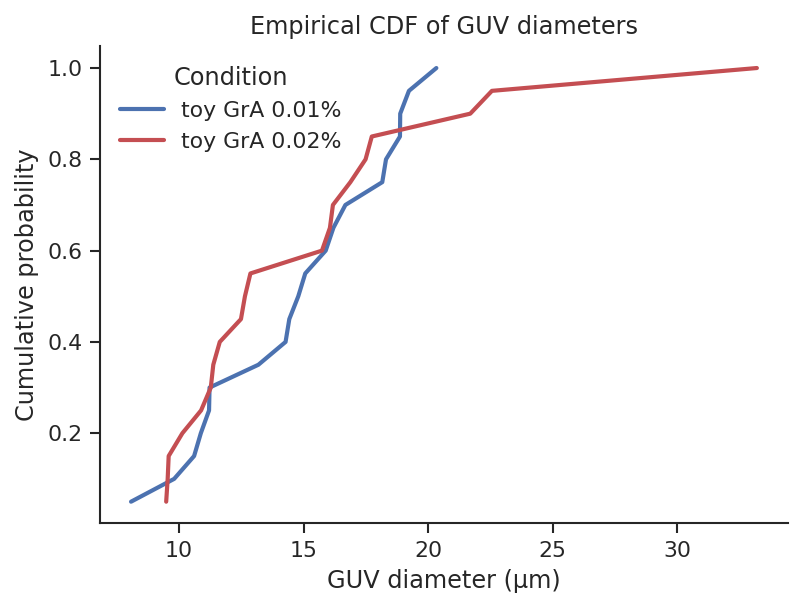

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))
for cond, grp in data.groupby("condition"):
    x = np.sort(grp["diameter_um"].values)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, color=palette[cond], lw=2, label=cond)
ax.set_xlabel("GUV diameter (µm)")
ax.set_ylabel("Cumulative probability")
ax.set_title("Empirical CDF of GUV diameters")
ax.legend(title="Condition", frameon=False)
sns.despine()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig3_ecdf.png", dpi=300)
fig.savefig(f"{FIG_DIR}/fig3_ecdf.svg")
plt.show()


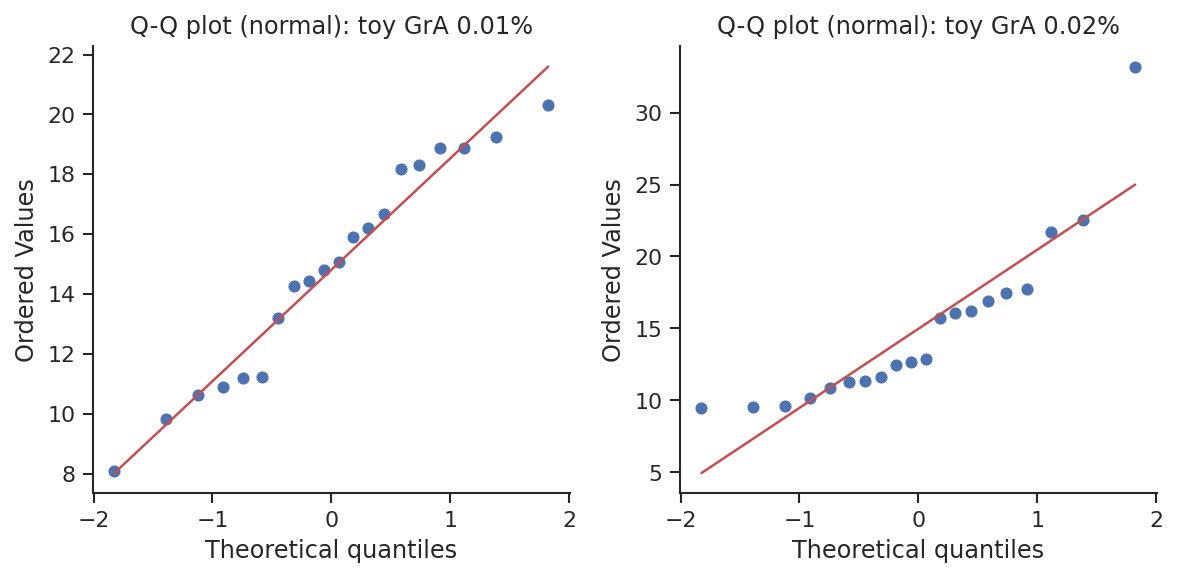

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (cond, grp) in zip(axes, data.groupby("condition")):
    stats.probplot(grp["diameter_um"], dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot (normal): {cond}")
sns.despine()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig4_qq_normal.png", dpi=300)
plt.show()


## 6. Next steps if raw microscopy images become available

The workbook here only has extracted diameters. If you also have the original phase-contrast
or confocal images the diameters were measured from, the following becomes possible and would
extend this notebook into a full image-analysis pipeline:

1. **Vesicle detection & segmentation** — Hough circle transform or a trained model
   (Cellpose / StarDist) per image; watershed for touching vesicles.
2. **Diameter / area / circularity extraction per vesicle** — from segmented contours
   (`skimage.measure.regionprops`), giving *independently measured* area and circularity
   rather than the sphere-assumption values computed in Section 1.
3. **Shape-deformation quantification** — circularity, aspect ratio, and Fourier-shape
   descriptors per contour, useful for detecting Gramicidin A-induced membrane perturbation
   beyond simple size changes.
4. **Population statistics across vesicles** — as in Sections 2–4 above, but now with
   independent shape and size variables.
5. **Correlation with the manually recorded Excel measurements** — a sanity check that
   automated segmentation reproduces the manual sizing in this workbook (Bland-Altman plot,
   Pearson/Spearman correlation).
6. **Publication-quality plots** — as in Section 5, extended with shape-vs-size scatter plots.
7. **GitHub-ready notebook structure** — split into `01_exploratory_analysis.ipynb` (this
   notebook), `02_image_segmentation.ipynb`, `03_shape_analysis.ipynb`,
   `04_correlation_with_manual_counts.ipynb`, with shared helper functions in a `src/` module.

Without images, steps 1–3 and 5 are not possible from this file alone.